# Giai đoạn 2: Phân tích Khám phá Dữ liệu và Trực quan hóa
Khám phá dữ liệu để xác định các khu vực có tỷ lệ tội phạm bạo lực và phi bạo lực cao nhất tại Hoa Kỳ.
Đồng thời, thông qua hệ số tương quan Pearson và trực quan hóa để giải đáp 5 giả thuyết kinh tế - xã hội:
1. **Tuổi tác:** Dân số trẻ có làm tăng tội phạm?
2. **Giáo dục:** Học vấn cao có giúp kìm hãm bạo lực?
3. **Kinh tế:** Nghèo đói có tạo ra "căng thẳng xã hội" dẫn đến tội phạm?
4. **Nhập cư:** Cộng đồng nhập cư có thực sự tỷ lệ thuận với tội phạm?
5. **Dân tộc:** Yếu tố sắc tộc có mối liên hệ nào với an ninh cộng đồng?


In [46]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv
load_dotenv()

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [47]:
#Load dataset đã làm sạch
load_dotenv(dotenv_path="../.env")

data_path = os.getenv("PROCESSED_DATA_PATH")

if data_path:
    print(f"Đang đọc dữ liệu từ đường dẫn cấu hình: {data_path}")
    df = pd.read_csv(data_path)

    print(f"Tải dữ liệu thành công! Tổng số dòng: {len(df)}")
    display(df.head())
else:
    print("Lỗi: Không tìm thấy file!")

Đang đọc dữ liệu từ đường dẫn cấu hình: ../data/processed/cleaned_crime_data.csv
Tải dữ liệu thành công! Tổng số dòng: 2215


,communityname,State,fold,pop,perHoush,pctBlack,pctWhite,pctAsian,pctHisp,pct12-21,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,violentPerPop,nonViolPerPop
0,BerkeleyHeightstownship,NJ,1,11980,3.10,1.37,91.78,6.50,1.88,12.47,...,14.0,114.85,138.0,1132.08,16.0,131.26,2.0,16.41,41.02,1394.59
1,Marpletownship,PA,1,23123,2.82,0.80,95.57,3.44,0.85,11.01,...,57.0,242.37,376.0,1598.78,26.0,110.55,1.0,4.25,127.56,1955.95
2,Tigardcity,OR,1,29344,2.43,0.74,94.33,3.43,2.35,11.36,...,274.0,758.14,1797.0,4972.19,136.0,376.30,22.0,60.87,218.59,6167.51
3,Gloversvillecity,NY,1,16656,2.40,1.70,97.35,0.50,0.70,12.55,...,225.0,1301.78,716.0,4142.56,47.0,271.93,5.0,21.08,306.64,4425.45
4,Bemidjicity,MN,1,11245,2.76,0.53,89.16,1.17,0.52,24.46,...,91.0,728.93,1060.0,8490.87,91.0,728.93,5.0,40.05,374.06,9988.79


In [48]:
import os
from dotenv import load_dotenv

target_var = "violentPerPop"


crime_cols = ['murders', 'murdPerPop', 'rapes', 'rapesPerPop', 'robberies', 'robbbPerPop',
              'assaults', 'assaultPerPop', 'burglaries', 'burglPerPop', 'larcenies', 'larcPerPop',
              'autoTheft', 'autoTheftPerPop', 'arsons', 'arsonsPerPop', 'nonViolPerPop']

df = df.drop(columns=[c for c in crime_cols if c in df.columns])


load_dotenv()
output_path = os.getenv("PROCESSED_DATA_PATH_TEMP")

os.makedirs(os.path.dirname(output_path), exist_ok=True)

df.to_csv(output_path, index=False)
print(f'Đã lưu thành công: "{output_path}"')

Đã lưu thành công: "../data/temp/temp_crime_data.csv"


## 1. Bản đồ nhiệt địa lý

### a. Tỷ lệ tội phạm bạo lực tại các bang nước Mỹ: murder, rape, robbery, and assault.

In [49]:
# 1. Chọn các cột cần thiết và loại bỏ các dòng có giá trị thiếu
crime_EDA_1 = df[["State", "pop", "violentPerPop"]].dropna()

# 2. Tính tổng số vụ tội phạm bạo lực cho từng khu vực
crime_EDA_1["total_violent_crimes"] = (
    crime_EDA_1["violentPerPop"] / 100000
) * crime_EDA_1["pop"]

# 3. Gom nhóm theo bang và tính tổng
state_groups = (
    crime_EDA_1.groupby("State")
    .agg(tot_pop=("pop", "sum"), tot_vio=("total_violent_crimes", "sum"))
    .reset_index()
)

# Tính toán tỷ lệ tội phạm của từng bang
state_groups["crime_rate"] = state_groups["tot_vio"] / state_groups["tot_pop"]

state_groups_sorted = state_groups.sort_values(by="crime_rate", ascending=False)

# In kết quả để validate
print(state_groups_sorted)

# 4. Tạo thông tin hiển thị
state_groups["hover_text"] = (
    state_groups["State"].astype(str)
    + "<br>pop: "
    + state_groups["tot_pop"].map("{:,}".format)
)

# 5. Vẽ bản đồ
fig = px.choropleth(
    state_groups,
    locations="State",
    locationmode="USA-states",
    color="crime_rate",
    hover_name="State",
    color_continuous_scale="Reds",
    labels={"crime_rate": "Tỷ lệ tội phạm bạo lực"},
    scope="usa",
    title="Tỷ lệ tội phạm bạo lực tại các bang nước Mỹ",
)


fig.update_traces(marker_line_color="white", marker_line_width=2)

# Hiển thị bản đồ
fig.show()

   State   tot_pop        tot_vio  crime_rate
7     DC    606900   18500.618220    0.030484
19    MD    981159   25298.780649    0.025785
31    NY   9474916  172887.554684    0.018247
17    LA   1537451   27312.461019    0.017765
10    GA   1601370   26269.735330    0.016405
9     FL   4594142   73943.688810    0.016095
37    SC    791754   12251.003968    0.015473
29    NM    582205    7791.111774    0.013382
1     AL   1686941   22472.282799    0.013321
2     AR    816863   10342.274771    0.012661
39    TN   1685221   20744.003938    0.012309
4     CA  22223516  266182.801503    0.011978
25    NC   2049543   23900.314186    0.011661
14    IN   2371482   23798.310729    0.010035
23    MO   1546912   15229.417636    0.009845
8     DE     27630     245.158227    0.008873
33    OK   1727382   15196.535346    0.008797
15    KS    304011    2659.153816    0.008747
44    WA   1943157   16947.578752    0.008722
32    OH   4823493   41708.158475    0.008647
35    PA   4247131   35430.092446 

Kết luận: Số liệu cho thấy Đặc khu Columbia (D.C.) dẫn đầu về tỷ lệ tội phạm bạo lực tại Hoa Kỳ. Theo sau D.C., Maryland là bang có tỷ lệ tội phạm bạo lực cao thứ hai, tiếp đến là New York, Louisiana, Georgia, Florida, South Carolina và Minnesota. Đáng chú ý, Maryland và D.C. có tỷ lệ tội phạm vượt trội hơn hẳn so với các bang còn lại trong nhóm, vốn có tỷ lệ gần như tương đương nhau. Mặt khác, New York và Florida lại có quy mô dân số lớn hơn rất nhiều so với các bang khác trong danh sách.

Kết luận: Đặc khu Columbia tiếp tục đứng đầu, theo sau là Florida, Maryland, Georgia, Louisiana và một bất ngờ là bang Washington; các bang này đều có tỷ lệ tội phạm phi bạo lực xấp xỉ nhau. Một điểm thú vị đáng ghi nhận là New York chỉ đứng thứ 23 trong danh sách các bang có tỷ lệ tội phạm phi bạo lực cao nhất, nhưng lại đứng thứ 3 về tội phạm bạo lực. Điều này có thể bắt nguồn từ việc các loại tội phạm phi bạo lực như trộm cắp tài sản tại New York thấp hơn đáng kể.

### c. Tỷ lệ phần trăm người Mỹ gốc Phi

In [50]:


# 1. Chọn các cột cần thiết và loại bỏ các dòng có giá trị thiếu
crime_EDA_3 = df[["State", "pop", "pctBlack"]].dropna()

# 2. Tính số lượng người Mỹ gốc Phi cho từng khu vực
crime_EDA_3["black_pop_absolute"] = crime_EDA_3["pctBlack"] * crime_EDA_3["pop"]

# 3. Gom nhóm theo bang và tính tổng
state_groups = (
    crime_EDA_3.groupby("State")
    .agg(
        tot_pop=("pop", "sum"), tot_black_pop=("black_pop_absolute", "sum")
    )
    .reset_index()
)

# Tính tỷ lệ phần trăm người Mỹ gốc Phi của từng bang
state_groups["black_pop_rate"] = (
    state_groups["tot_black_pop"] / state_groups["tot_pop"]
) * 100

# 4. Tạo thông tin hiển thị
state_groups["hover_text"] = (
    state_groups["State"].astype(str)
    + "<br>pop: "
    + state_groups["tot_pop"].map("{:,}".format)
)

# 5. Vẽ bản đồ
fig = px.choropleth(
    state_groups,
    locations="State",
    locationmode="USA-states",
    color="black_pop_rate",
    hover_name="State",
    hover_data={
        "State": False,
        "black_pop_rate": ":.2f",
    },
    color_continuous_scale="Blues",
    labels={"black_pop_rate": "Tỷ lệ người Mỹ gốc Phi (%)"},
    scope="usa",
    title="Tỷ lệ phần trăm người Mỹ gốc Phi",
)


fig.update_traces(marker_line_color="white", marker_line_width=2)

# Hiển thị bản đồ
fig.show()

Kết luận: Về mặt nhân khẩu học, cộng đồng người Mỹ gốc Phi chiếm hơn 65% dân số của D.C. Các bang khác có tỷ lệ người Mỹ gốc Phi cao bao gồm Maryland, Georgia, Louisiana và Mississippi. Đây cũng chính là những bang nằm trong nhóm có tỷ lệ tội phạm bạo lực và phi bạo lực cao nhất. Sự trùng hợp này lý giải vì sao các vấn đề tội phạm thường dễ dẫn đến những định kiến về sắc tộc. Đây là một mối tương quan phức tạp cần được nghiên cứu và phân tích sâu hơn trong các phần tiếp theo.

## 2. Bản đồ chữ:

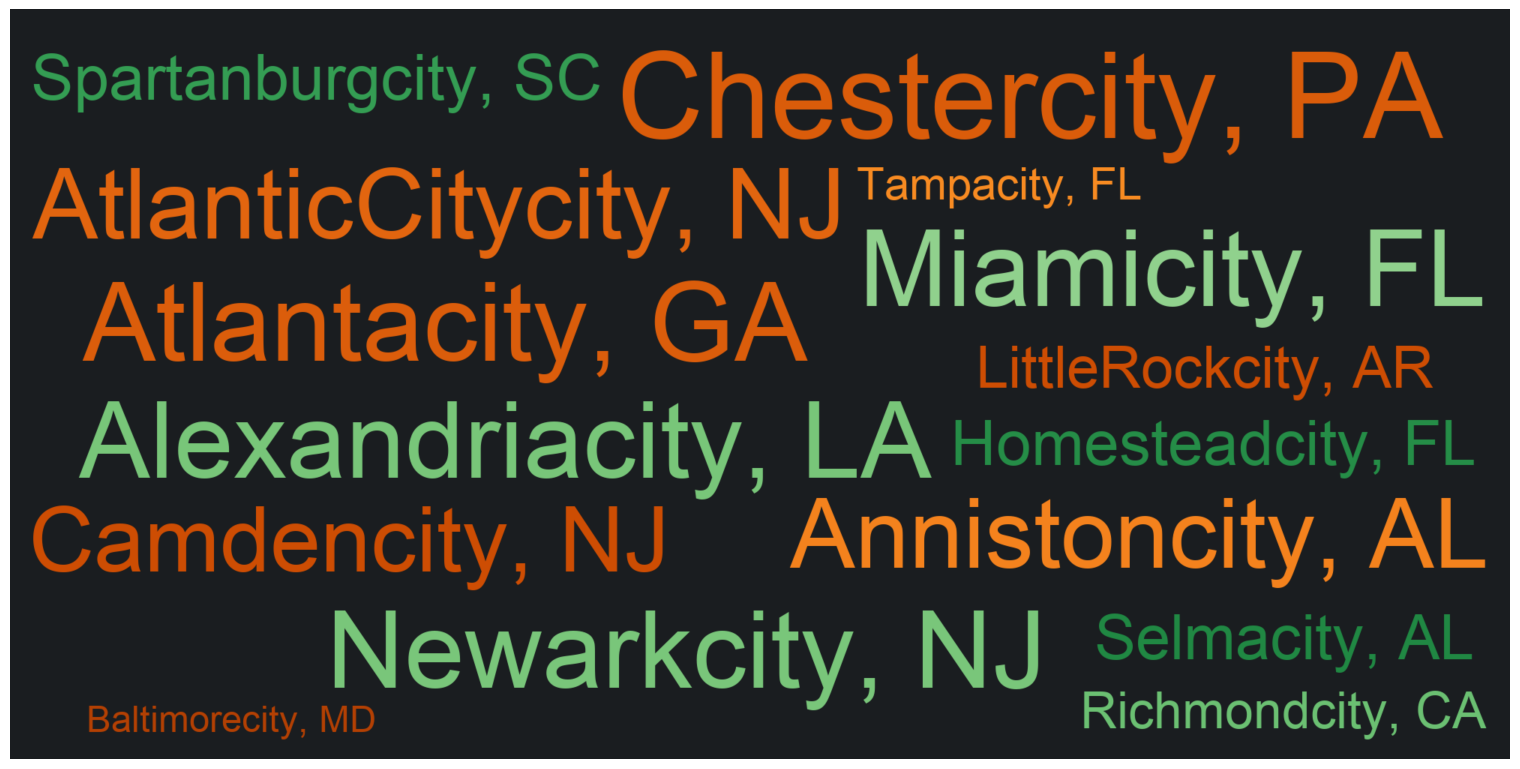

In [51]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from wordcloud import WordCloud

# 1. Chọn các cột cần thiết và loại bỏ các dòng có giá trị thiếu
crime_EDA_3 = df[["communityname", "State", "pop", "violentPerPop"]].dropna()

# 2. Tạo cột 'Place' kết hợp tên cộng đồng và Bang
crime_EDA_3["Place"] = (
    crime_EDA_3["communityname"].astype(str) + ", " + crime_EDA_3["State"].astype(str)
)

# 3. Tính tổng số vụ tội phạm bạo lực tuyệt đối dựa trên cột 'pop' và 'violentPerPop'
crime_EDA_3["total_violent_crimes"] = (
    crime_EDA_3["violentPerPop"] / 100000
) * crime_EDA_3["pop"]

# 4. Gom nhóm theo 'Place' và tính tổng
place_groups = (
    crime_EDA_3.groupby("Place")
    .agg(tot_pop=("pop", "sum"), tot_vio=("total_violent_crimes", "sum"))
    .reset_index()
)

# Tính toán tỷ lệ tội phạm trên 100,000 dân
place_groups["crime_rate"] = (
    place_groups["tot_vio"] / place_groups["tot_pop"]
) * 100000

# 5. Sắp xếp giảm dần và lấy Top 15 cộng đồng nguy hiểm nhất
top_15_communities = place_groups.sort_values(
    by="crime_rate", ascending=False
).head(15)

# 6. Chuyển đổi dữ liệu thành dạng Dictionary để nạp vào Word Cloud
data_dict = dict(zip(top_15_communities["Place"], top_15_communities["crime_rate"]))

# 7. Tạo Word Cloud
greens = plt.cm.get_cmap('Greens')(np.linspace(0.4, 0.9, 128)) # Bỏ các màu quá nhạt
yellows = plt.cm.get_cmap('YlOrBr')(np.linspace(0.5, 0.9, 128))
combined_colors = np.vstack((greens, yellows))
custom_colormap = mcolors.LinearSegmentedColormap.from_list('GreensYellows', combined_colors)

wordcloud = WordCloud(
    width=2000,
    height=1000,
    background_color="#1a1d20",
    colormap=custom_colormap,
    prefer_horizontal=1.0,
    random_state=42,
    collocations=False,
    min_font_size=10,
    max_font_size=160,
    font_path='Arial',
    margin=50
).generate_from_frequencies(data_dict)


# 8. Hiển thị
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Kết luận: Thành phố Baltimore chỉ xếp thứ 15 trong danh sách các cộng đồng nguy hiểm nhất Hoa Kỳ tính theo tỷ lệ tội phạm bạo lực. Những thành phố nguy hiểm nhất xét về tiêu chí này bao gồm thành phố Chester thuộc bang Pennsylvania, Atlanta, Newark, Alexandria thuộc bang Louisiana, Miami và Atlantic City. Trong đó, thành phố Chester có tỷ lệ tội phạm bạo lực đặc biệt cao, trong khi các thành phố như Atlanta, Miami và Newark lại sở hữu quy mô dân số vượt trội hơn hẳn so với những địa phương còn lại trong nhóm. Kết quả này cho thấy bức tranh tội phạm thực tế phức tạp hơn các định kiến thông thường và phụ thuộc lớn vào đặc điểm của từng đô thị cụ thể.

### 3. Tương quan của các yếu tố kinh tế - xã hội đến tỷ lệ tội phạm

Chúng tôi khép lại phần phân tích khám phá dữ liệu trực quan bằng việc xem xét các yếu t kinh tế - xã hội có tương quan như thế nào đến tỷ lệ tội phạm bạo lực.

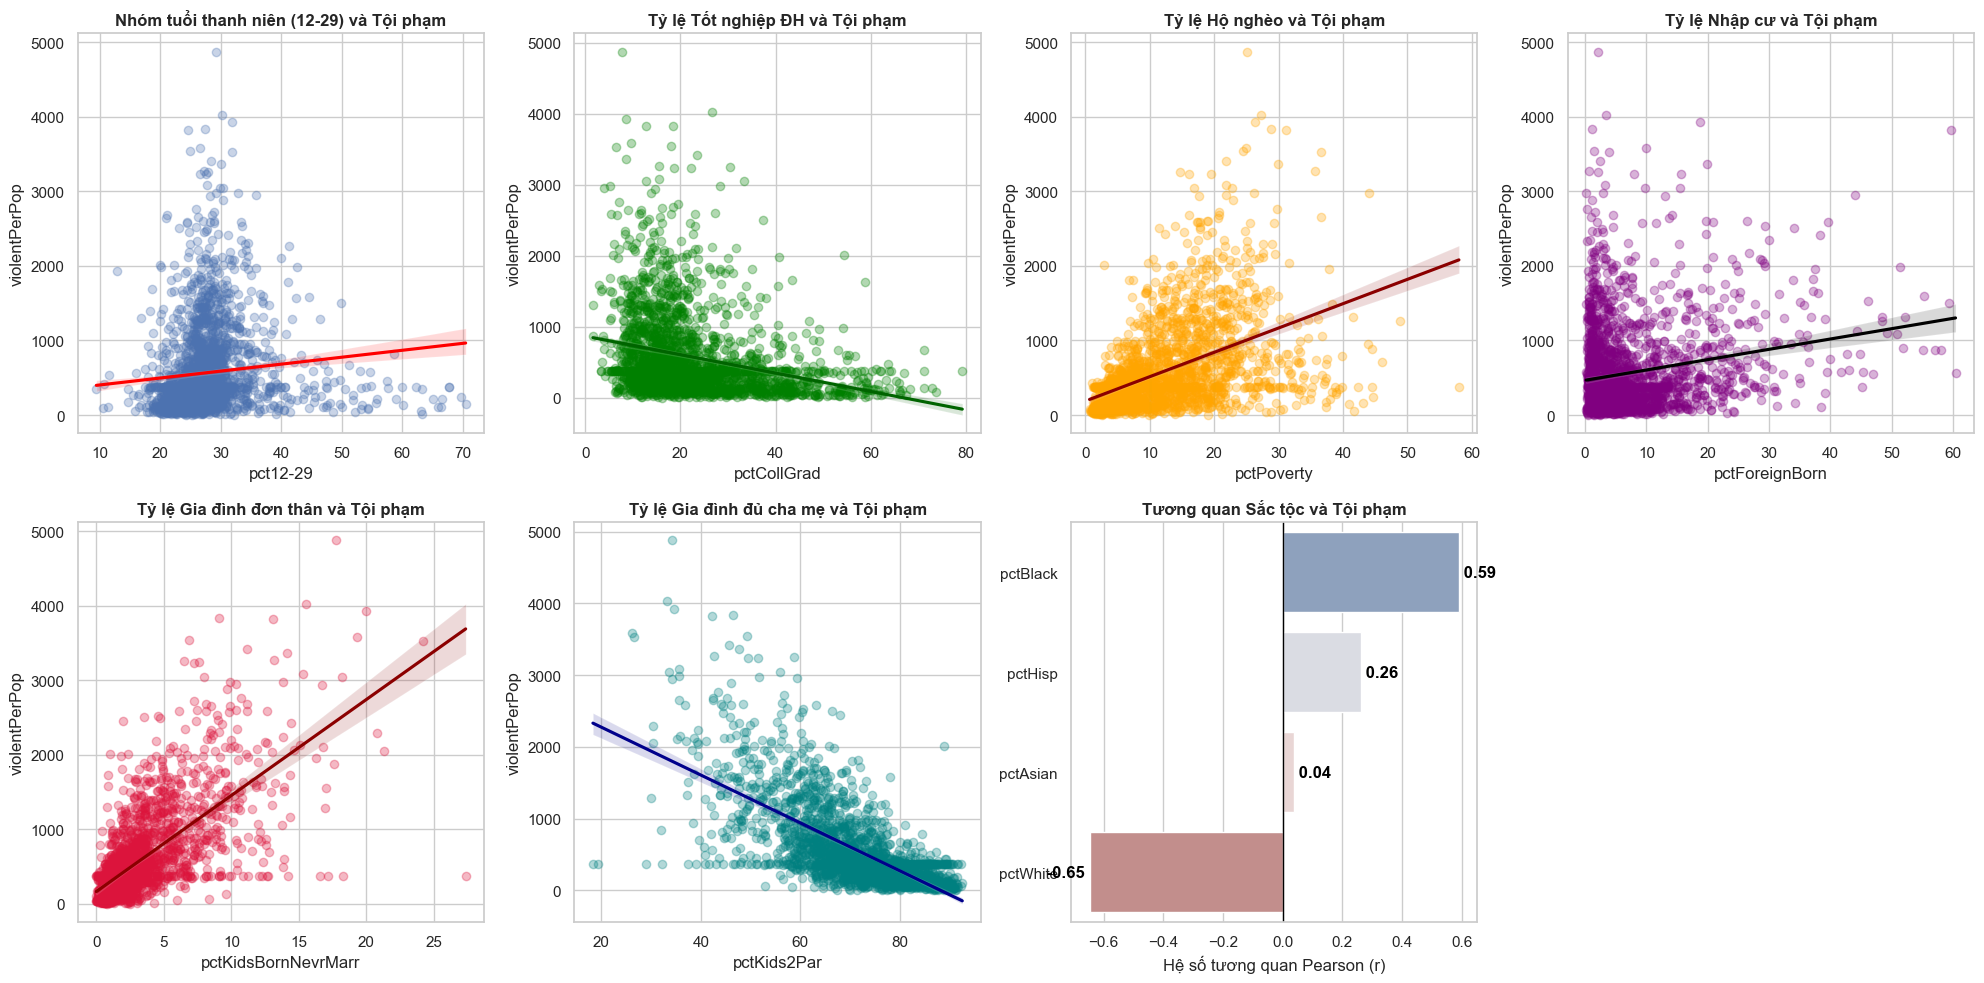

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dùng tên cột trực tiếp cho y để seaborn nhận diện tên trục mượt mà hơn
TARGET_COL = "violentPerPop"

# Mở rộng lưới thành 2 dòng x 4 cột (tổng 8 ô) để chứa thêm các biến gia đình
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

axes = axes.flatten()

# 1. Tuổi tác
sns.regplot(data=df, x='pct12-29', y=TARGET_COL, ax=axes[0], scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
axes[0].set_title('Nhóm tuổi thanh niên (12-29) và Tội phạm', fontweight='bold')

# 2. Giáo dục
sns.regplot(data=df, x='pctCollGrad', y=TARGET_COL, ax=axes[1], color='green', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'darkgreen'})
axes[1].set_title('Tỷ lệ Tốt nghiệp ĐH và Tội phạm', fontweight='bold')

# 3. Kinh tế
sns.regplot(data=df, x='pctPoverty', y=TARGET_COL, ax=axes[2], color='orange', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'darkred'})
axes[2].set_title('Tỷ lệ Hộ nghèo và Tội phạm', fontweight='bold')

# 4: Nhập cư
sns.regplot(data=df, x='pctForeignBorn', y=TARGET_COL, ax=axes[3], color='purple', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'black'})
axes[3].set_title('Tỷ lệ Nhập cư và Tội phạm', fontweight='bold')

# 5: Cấu trúc gia đình đơn thân
sns.regplot(data=df, x='pctKidsBornNevrMarr', y=TARGET_COL, ax=axes[4], color='crimson', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'darkred'})
axes[4].set_title('Tỷ lệ Gia đình đơn thân và Tội phạm', fontweight='bold')

# 6: Cấu trúc gia đình có đủ cha mẹ
sns.regplot(data=df, x='pctKids2Par', y=TARGET_COL, ax=axes[5], color='teal', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'darkblue'})
axes[5].set_title('Tỷ lệ Gia đình đủ cha mẹ và Tội phạm', fontweight='bold')

# 7: Sắc tộc
race_vars = ['pctBlack', 'pctWhite', 'pctAsian', 'pctHisp']

# Tính toán tương quan với biến mục tiêu và sắp xếp
race_corr = df[race_vars + [TARGET_COL]].corr()[[TARGET_COL]].drop(TARGET_COL)
race_corr = race_corr.sort_values(by=TARGET_COL, ascending=False)

# Vẽ biểu đồ cột ngang
sns.barplot(x=race_corr[TARGET_COL], y=race_corr.index, ax=axes[6], palette='vlag')


axes[6].set_title('Tương quan Sắc tộc và Tội phạm', fontweight='bold')
axes[6].set_xlabel('Hệ số tương quan Pearson (r)')
axes[6].set_ylabel('')
axes[6].axvline(0, color='black', linewidth=1) # Thêm đường trục 0 ở giữa để phân biệt âm/dương


for i, val in enumerate(race_corr[TARGET_COL]):
    axes[6].text(val, i, f" {val:.2f} ", va='center',
                 ha='left' if val > 0 else 'right', color='black', fontweight='bold')

# 8: Tắt trục của ô cuối cùng vì chỉ có 7 biểu đồ
axes[7].axis('off')

plt.tight_layout()
plt.show()

Qua biểu đồ phân tích, có thể thấy yếu tố kinh tế, cụ thể là tỷ lệ hộ nghèo, có tác động mạnh mẽ và trực tiếp nhất đến tỷ lệ tội phạm bạo lực. Trái lại, tỷ lệ tốt nghiệp đại học cho thấy mối tương quan nghịch rõ rệt, nhấn mạnh vai trò của giáo dục và sự ổn định kinh tế trong việc giảm thiểu tội phạm. Các yếu tố về độ tuổi thanh niên chỉ có tương quan dương nhẹ, trong khi tỷ lệ người nhập cư hầu như không thể hiện mối liên hệ đáng kể nào với tội phạm. Đặc biệt, đối với các chỉ số về sắc tộc, dù xuất hiện các hệ số tương quan đáng chú ý, nhưng cần hết sức thận trọng khi diễn giải; các kết quả này thường là hệ quả của những bất bình đẳng mang tính hệ thống như phân bổ nguồn lực và cơ hội hơn là bản chất sắc tộc. Nhìn chung, kết quả này cho thấy tội phạm là một vấn đề xã hội đa chiều, đòi hỏi phải sử dụng các mô hình hồi quy đa biến để tách biệt ảnh hưởng thực sự của từng biến số thay vì chỉ dựa vào tương quan đơn lẻ.

=== TOP 15 BIẾN KINH TẾ-XÃ HỘI CÓ TƯƠNG QUAN MẠNH NHẤT ===
(Đã loại trừ các biến thành phần của tội phạm)
pctKidsBornNevrMarr    0.686665
pctKids2Par           -0.684059
pct2Par               -0.649762
pctWhite              -0.647164
pct12-17w2Par         -0.616963
pctKids-4w2Par        -0.611884
pctBlack               0.590580
pctWdiv               -0.534563
pctFemDivorc           0.513018
pctAllDivorc           0.511019
pctPubAsst             0.507611
pctPersOwnOccup       -0.494272
pctMaleDivorc          0.485363
pctPoverty             0.478259
pctHousWOphone         0.462725
Name: violentPerPop, dtype: float64
--------------------------------------------------


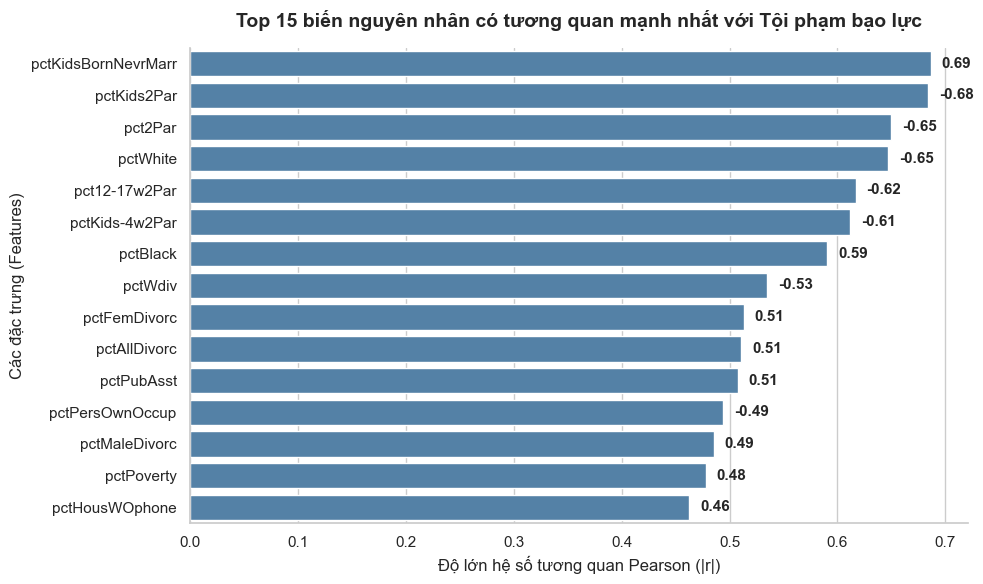

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 2. Tính toán tương quan của các biến còn lại với biến mục tiêu
numeric_df = df_eda.select_dtypes(include=[np.number])
all_correlations = numeric_df.corr()[[target_var]].drop(target_var)

# Thêm cột giá trị tuyệt đối để sắp xếp độ mạnh của tương quan
all_correlations['abs_corr'] = all_correlations[target_var].abs()
correlations_sorted = all_correlations.sort_values(by='abs_corr', ascending=False)

# Lấy Top 15 biến có ảnh hưởng mạnh nhất
top_15_vars = correlations_sorted.head(15)

print("=== TOP 15 BIẾN KINH TẾ-XÃ HỘI CÓ TƯƠNG QUAN MẠNH NHẤT ===")
print("(Đã loại trừ các biến thành phần của tội phạm)")
print(top_15_vars[target_var])
print("-" * 50)

# 3. Trực quan hóa so sánh

ax = sns.barplot(x=top_15_vars['abs_corr'], y=top_15_vars.index, color='steelblue')


plt.title('Top 15 biến nguyên nhân có tương quan mạnh nhất với Tội phạm bạo lực',
          fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Độ lớn hệ số tương quan Pearson (|r|)', fontsize=12)
plt.ylabel('Các đặc trưng (Features)', fontsize=12)


for i, (index, row) in enumerate(top_15_vars.iterrows()):
    actual_corr = row[target_var]
    ax.text(row['abs_corr'] + 0.01, i, f"{actual_corr:.2f}", va='center', fontsize=11, fontweight='bold')


sns.despine()
plt.tight_layout()
plt.show()